In [1]:
# Imports 
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
import sqlite3

In [44]:
# Constants

# MediaPipe joint indices (33 joints)
LEFT_HIP = 23
RIGHT_HIP = 24
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_KNEE = 25
RIGHT_KNEE = 26
LEFT_ANKLE = 27
RIGHT_ANKLE = 28

NUM_JOINTS = 33 # All Mediapipe landmarkers

GAIT_JOINTS = [
    2, 5,     # eyes (head orientation)
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

GAIT_JOINT_INDEX = {joint_id: i for i, joint_id in enumerate(GAIT_JOINTS)}

#Target labels
LABEL_MAP = {
    "normal": 0,
    "abnormal": 1
}


In [3]:
# Load data from MediaPipe Pose stored in Parquet file

df = pl.read_parquet('/Users/pierre/Documents/NF_Bootcamp/Capstone/GAITy-Capstone-Modeling/data/filled_gait_data_encoded.parquet')


In [4]:
# 0 Data cleaning: 

#Fill null values with "N"
df = df.with_columns(
    pl.col("movement_type").fill_null("N")
)
# Remove columns with slowmotion videos and fill null values in movement type
df = df.filter(
    pl.col("movement_type") != "SLOWMOTION"
)

#Fill null values with "N" for gait:markers
df = df.with_columns(
    pl.col("gait_markers").fill_null("NA")
)

In [5]:
# 1. Data cleaning: Remove videos with high percentage of missing frames 

def missing_frames_summary_polars(df: pl.DataFrame, video_col="video_id", frame_col="frame"):
    """
    Compute number and % of missing frames per video.
    
    Returns:
        summary: dict with overall stats
        frame_stats: Polars DataFrame with per-video missing frames info
    """
    # Count unique frames per video
    unique_counts = (
        df.group_by(video_col)
          .agg(pl.col(frame_col).n_unique().alias("num_unique_frames"))
    )

    # Min/max frame per video
    frame_range = (
        df.group_by(video_col)
          .agg([
              pl.col(frame_col).min().alias("min_frame"),
              pl.col(frame_col).max().alias("max_frame")
          ])
    )

    # Join to compute missing frames
    frame_stats = unique_counts.join(frame_range, on=video_col)

    # Compute missing frames and percentage
    frame_stats = frame_stats.with_columns([
        (pl.col("max_frame") - pl.col("min_frame") + 1 - pl.col("num_unique_frames")).alias("num_missing_frames"),
        ((pl.col("max_frame") - pl.col("min_frame") + 1 - pl.col("num_unique_frames")) /
         (pl.col("max_frame") - pl.col("min_frame") + 1) * 100).alias("pct_missing")
    ])

    # Overall summary stats
    summary = {
        "mean_missing": frame_stats["num_missing_frames"].mean(),
        "std_missing": frame_stats["num_missing_frames"].std(),
        "max_missing": frame_stats["num_missing_frames"].max(),
        "mean_pct_missing": frame_stats["pct_missing"].mean()
    }

    # Order by descending number of missing frames
    frame_stats = frame_stats.sort("num_missing_frames", descending=True)

    return summary, frame_stats



def filter_videos_by_missing_frames(df: pl.DataFrame, video_col="video_id", frame_col="frame", threshold_pct=5.0):
    """
    Filter out videos where the percentage of missing frames exceeds threshold_pct.
    
    Args:
        df: Polars DataFrame with per-frame landmarks
        video_col: column identifying videos
        frame_col: column with frame numbers
        threshold_pct: maximum allowed percentage of missing frames (e.g., 5.0)
    
    Returns:
        filtered_df: DataFrame with videos below the missing frame threshold
        removed_videos: list of video_ids that were removed
    """
    
    # Compute missing frames per video
    _, frame_stats = missing_frames_summary_polars(df, video_col=video_col, frame_col=frame_col)
    
    # Find videos to keep
    videos_to_keep = frame_stats.filter(pl.col("pct_missing") <= threshold_pct)[video_col].to_list()
    
    # Filter original dataframe
    filtered_df = df.filter(pl.col(video_col).is_in(videos_to_keep))
    
    # List of removed videos for logging
    removed_videos = frame_stats.filter(pl.col("pct_missing") > threshold_pct)[video_col].to_list()
    
    return filtered_df, removed_videos


In [6]:
# 2. Data Interpolation Function: for missing frames in order to keep temporal integrity of the video sequence:

def interpolate_pose(pose: np.ndarray) -> np.ndarray:
    """
    Linearly interpolate missing frames (zeros) in a pose tensor.
    pose: (T, J, 3)
    """
    T, J, C = pose.shape
    pose_interp = pose.copy()

    for j in range(J):
        for c in range(C):
            coord = pose[:, j, c]
            missing = coord == 0  # detect missing frames
            if missing.all():
                continue  # skip if all frames missing
            valid_idx = np.where(~missing)[0]
            valid_values = coord[valid_idx]
            # linear interpolation across all T
            pose_interp[:, j, c] = np.interp(np.arange(T), valid_idx, valid_values)
    
    return pose_interp


In [7]:
# 3. Convert pose coordinates into pose column AND Group rows(frames & landmarkers) by each video
# Output: A new DataFrame where each row corresponds to one video, and includes a pose column.

def add_pose_column(df: pl.DataFrame) -> pl.DataFrame:
    pose_rows = []

    for video_id in df.select("video_id").unique().to_series():
        group = df.filter(pl.col("video_id") == video_id).sort("frame")

        frames = np.sort(group["frame"].unique().to_numpy())
        frame_to_idx = {f: i for i, f in enumerate(frames)}

        T = len(frames)
        pose = np.zeros((T, NUM_JOINTS, 3), dtype=np.float32)

        for row in group.iter_rows(named=True):
            f_idx = frame_to_idx[row["frame"]]
            j = int(row["landmark_id"])
            if j >= NUM_JOINTS:
                continue  # skip any bad IDs
            pose[f_idx, j, :] = [row["x_norm"], row["y_norm"], row["z_norm"]]

        # Interpolation across all 33 joints
        pose = interpolate_pose(pose)

        base_row = group.row(0, named=True)
        base_row["pose"] = pose
        pose_rows.append(base_row)

    return pl.DataFrame(pose_rows)

In [8]:
# 4. Normalize the Pose

def normalize_pose_3d(pose):  
    #pose: (T,J,3)
    
    # Joint indices
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12

    # pelvis per frame (midpoint of hips)
    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2.0   # (T, 3)

    # center all joints around pelvis
    pose_centered = pose - pelvis[:, None, :]           # (T, J, 3)

    # torso vector: midpoint of shoulders (already pelvis-centered)
    torso = (pose_centered[:, LEFT_SHOULDER] +
             pose_centered[:, RIGHT_SHOULDER]) / 2.0          # (T, 3)

    # single scale per sequence: avg torso length
    scale = np.linalg.norm(torso, axis=1).mean() 

    if scale == 0 or not np.isfinite(scale):
        raise ValueError("Invalid torso scale during pose normalisation")


    # All coordinates are now expressed in units of torso_length, making them more comparable across subjects
    pose_scaled = pose_centered / scale 

    return pose_scaled

"""
#Removed:
✔ Body size differences
✔ Camera distance effects
Preserved:
✔ Relative joint motion
✔ Asymmetry
✔ Trunk lean & pelvic drop
✔ Temporal dynamics
"""


'\n#Removed:\n✔ Body size differences\n✔ Camera distance effects\nPreserved:\n✔ Relative joint motion\n✔ Asymmetry\n✔ Trunk lean & pelvic drop\n✔ Temporal dynamics\n'

In [9]:
# 5. Extract sliding windows

def extract_sliding_windows(
    pose: np.ndarray,
    fps: int = 30,
    window_seconds: float = 2.0,
    overlap: float = 0.5
):
    """
    Split pose sequence into sliding windows.
    
    Args:
        pose: (T, J, 3) normalized pose array
        fps: frames per second
        window_seconds: length of window in seconds
        overlap: fraction overlap between windows (0.0-1.0)
    
    Returns:
        List of pose windows: each (window_frames, J, 3)
    """
    T, J, C = pose.shape
    window_frames = int(window_seconds * fps)
    step_frames = int(window_frames * (1 - overlap))

    if window_frames > T:
        # If video is shorter than window, return single padded window
        return [pose]

    windows = []
    start = 0
    while start + window_frames <= T:
        window = pose[start:start + window_frames]
        windows.append(window)
        start += step_frames

    # Optional: include last partial window if remaining frames > 50% of window
    if start < T and (T - start) >= int(0.5 * window_frames):
        window = pose[T - window_frames : T]
        windows.append(window)

    return windows

In [14]:
# 6. Gait Preprocessing Pipeline
# ---------------------------
from scipy.signal import resample
import numpy as np

def preprocess_gait_sliding_windows(
    df_video: pl.DataFrame,
    window_seconds: float = 2.0,
    overlap: float = 0.5,
    resample_frames: int = 60
):
    """
    Preprocess gait data using sliding windows, resampling each window to a fixed frame count.

    Returns:
        X_windows: (N_windows, resample_frames, len(GAIT_JOINTS), 3)
        y_labels: (N_windows,)
        window_ids: list of unique IDs for each window
    """
    all_windows = []
    all_labels = []
    all_window_ids = []

    for idx, row in enumerate(df_video.iter_rows(named=True)):
        pose = row["pose"]
        if pose is None:
            continue

        pose = np.asarray(pose)
        if pose.size == 0 or pose.ndim != 3:
            print(f"Row {idx} has invalid pose shape: {pose.shape}")
            continue

        fps = row.get("fps", 30) or 30

        # Label mapping
        label_str = str(row.get("dataset", "none")).strip().lower()
        label = LABEL_MAP.get(label_str, 0)

        # Normalize pose
        try:
            pose_norm = normalize_pose_3d(pose)
        except Exception as e:
            print(f"Skipping row {idx} due to normalization error: {e}")
            continue

        # Extract sliding windows
        windows = extract_sliding_windows(
            pose_norm,
            fps=fps,
            window_seconds=window_seconds,
            overlap=overlap
        )

        # Select gait joints only
        windows = [w[:, GAIT_JOINTS, :] for w in windows]

        video_id = row.get("video_id", f"vid{idx}")

        # Loop over windows to assign unique IDs and resample
        for win_idx, w in enumerate(windows):
            # Resample to fixed number of frames
            if w.shape[0] < 2:  # skip trivially short windows
                continue
            w_resampled = resample(w, resample_frames, axis=0)

            # Generate window ID
            start_frame = win_idx * int(window_seconds * fps * (1 - overlap))
            end_frame = start_frame + w_resampled.shape[0] - 1
            window_id = f"{video_id}_win{win_idx:03d}_f{start_frame}-{end_frame}"

            # Append to lists
            all_windows.append(w_resampled)
            all_labels.append(label)
            all_window_ids.append(window_id)

    # Convert to NumPy arrays
    X_windows = np.asarray(all_windows, dtype=np.float32)
    y_labels = np.asarray(all_labels, dtype=np.int32)

    return X_windows, y_labels, all_window_ids



In [15]:
# 8. Usage

# ---------------------------
# Step 0: Filter videos with too many missing frames
# ---------------------------
df_clean, removed_videos = filter_videos_by_missing_frames(
    df, video_col="video_id", frame_col="frame", threshold_pct=5.0
)

print(f"Removed {len(removed_videos)} videos due to missing frames:")
print(removed_videos)

print(f"Remaining dataframe has {df_clean['video_id'].n_unique()} videos")

Removed 19 videos due to missing frames:
['semantic_segmentation_PA027_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA366_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA250_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA203_UGS_WoJ_1_DensePose_landmarks', 'semantic_segmentation_PA239_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA016_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA292_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA140_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA267_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA375_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA337_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA031_UGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA336_UGS_WJ_2_DensePose_landmarks', 'semantic_segmentation_PA026_FGS_WoJ_2_DensePose_landmarks', 'semantic_segmentation_PA383_UGS_WJ_2_DensePose_lan

In [17]:
# ---------------------------
# Step 1: Convert pose coordinates into pose column with interpolation
# ---------------------------
df_video = add_pose_column(df_clean)
print(f"Pose column added. Example shape: {df_video['pose'][0].shape}")

# ---------------------------
# Step 2: Preprocess gait dataframe using sliding windows
# ---------------------------
X_windows, y_labels, window_ids = preprocess_gait_sliding_windows(
    df_video,
    window_seconds=2.0,
    overlap=0.5,
    resample_frames=60
)

print(f"X_windows shape: {X_windows.shape}")
print(f"y_labels shape: {y_labels.shape}")
print(f"First 5 window IDs: {window_ids[:5]}")



Pose column added. Example shape: (158,)
X_windows shape: (15752, 60, 14, 3)
y_labels shape: (15752,)
First 5 window IDs: ['semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win000_f0-59', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win001_f33-92', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win002_f66-125', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win003_f99-158', 'semantic_segmentation_PA324_FGS_WoJ_1_DensePose_landmarks_win000_f0-59']


Notes & Advantages
FPS aware: Each video uses its own FPS to compute window frames (60 vs 33).
Overlapping windows: 50% overlap ensures smooth coverage and more samples.
Handles short videos: Automatically includes last partial window if >50% of window length.
Directly compatible with feature calculation: Each window can now be aggregated into your existing features like step_L_mean_step_time, knee_ROM, etc.
Avoids unreliable heel-strike detection: No need for peak detection on heel markers.
One row per window: Perfect for XGBoost.

In [19]:
print("X_windows shape:", X_windows.shape)   # (windows, frames, joints, coords)
print("y_labels shape:", y_labels.shape)
print("Window IDs example:", window_ids[:5])

# Check min/max values across all coordinates
print("X_windows min:", X_windows.min())
print("X_windows max:", X_windows.max())

# Check for NaNs or infs
print("Any NaNs?", np.isnan(X_windows).any())
print("Any Infs?", np.isinf(X_windows).any())


X_windows shape: (15752, 60, 14, 3)
y_labels shape: (15752,)
Window IDs example: ['semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win000_f0-59', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win001_f33-92', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win002_f66-125', 'semantic_segmentation_PA083_FGS_WoJ_1_DensePose_landmarks_win003_f99-158', 'semantic_segmentation_PA324_FGS_WoJ_1_DensePose_landmarks_win000_f0-59']
X_windows min: -3.3922167
X_windows max: 4.174513
Any NaNs? False
Any Infs? False


In [23]:
# Check distribution of classes: Should be roughly 70-90% normal
print("Normal vs abnormal:", np.unique(y_labels, return_counts=True))


Normal vs abnormal: (array([0, 1], dtype=int32), array([14877,   875]))


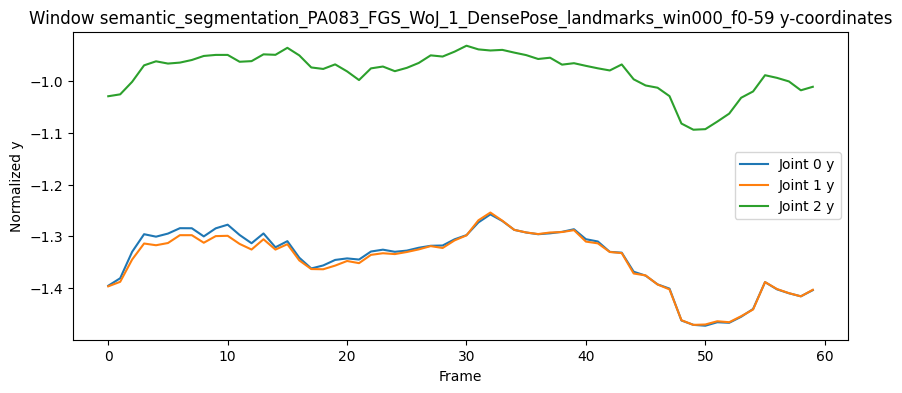

In [24]:
window_idx = 0  # pick a window
window = X_windows[window_idx]

# Example: y-coordinate trajectories for hips, knees, ankles
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(window[:, 0, 1], label="Joint 0 y")  # replace 0 with joint index
plt.plot(window[:, 1, 1], label="Joint 1 y")
plt.plot(window[:, 2, 1], label="Joint 2 y")
plt.title(f"Window {window_ids[window_idx]} y-coordinates")
plt.xlabel("Frame")
plt.ylabel("Normalized y")
plt.legend()
plt.show()


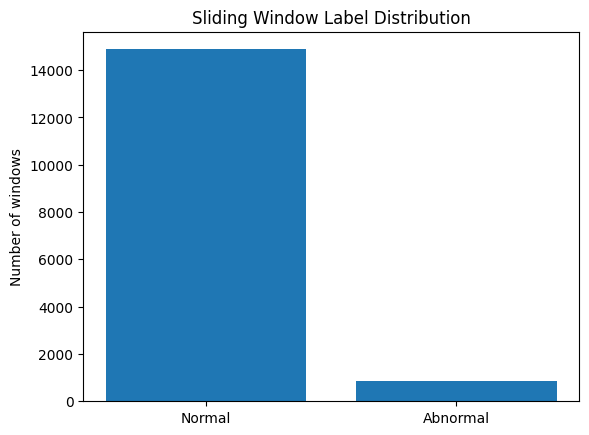

Label counts: {0: 14877, 1: 875}


In [ ]:
# Label distribution

import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y_labels, return_counts=True)
plt.bar([str(u) for u in unique], counts)
plt.xticks([0,1], ["Normal","Abnormal"])
plt.ylabel("Number of windows")
plt.title("Sliding Window Label Distribution")
plt.show()

print("Label counts:", dict(zip(unique, counts)))


In [ ]:
#Calculate class sample_weights for XGBoost!
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y_labels)


In [27]:
# Analyze Window Durations & Subjects

from collections import Counter

subject_ids = [w.split("_")[0] for w in window_ids]  # assuming first part of ID = video/subject
window_counts = Counter(subject_ids)

print("Min windows per subject:", min(window_counts.values()))
print("Max windows per subject:", max(window_counts.values()))
print("Example:", list(window_counts.items())[:5])


Min windows per subject: 1
Max windows per subject: 14877
Example: [('semantic', 14877), ('cll7p882j00053o6lf14c7el3', 6), ('cll7qjcba006q3o6lzz0lkvdi', 4), ('cll8fbyl500543o6lfryeb4cy', 6), ('cll9xchd900143o6lj63k8c6r', 5)]


**Quality Checks**

In [35]:
def sliding_window_quality_check_simple(X_windows, y_labels, plot=True):
    """
    Quality checks for sliding-window gait data (GAIT_JOINTS only).
    """

    N, T, J, C = X_windows.shape

    # Map global → local indices
    GAIT_JOINT_INDEX = {joint_id: i for i, joint_id in enumerate(GAIT_JOINTS)}

    L_HIP = GAIT_JOINT_INDEX[23]
    R_HIP = GAIT_JOINT_INDEX[24]
    L_SHOULDER = GAIT_JOINT_INDEX[11]
    R_SHOULDER = GAIT_JOINT_INDEX[12]
    L_ANKLE = GAIT_JOINT_INDEX[27]
    R_ANKLE = GAIT_JOINT_INDEX[28]

    # -----------------------------
    # A) Integrity
    # -----------------------------
    invalid_windows = (
        np.isnan(X_windows).any(axis=(1,2,3)) |
        np.isinf(X_windows).any(axis=(1,2,3))
    )

    # -----------------------------
    # B) Normalisation sanity checks
    # -----------------------------
    pelvis = (X_windows[:,:,L_HIP,:] + X_windows[:,:,R_HIP,:]) / 2
    pelvis_offset = np.linalg.norm(pelvis.mean(axis=1), axis=1)

    torso = (
        (X_windows[:,:,L_SHOULDER,:] + X_windows[:,:,R_SHOULDER,:]) / 2
        - pelvis
    )
    torso_lengths = np.linalg.norm(torso, axis=2)
    torso_mean = torso_lengths.mean(axis=1)

    # -----------------------------
    # C) Motion magnitude
    # -----------------------------
    joint_motion = np.std(X_windows, axis=1)
    mean_motion = joint_motion.mean(axis=(1,2))
    low_motion_windows = mean_motion < np.percentile(mean_motion, 5)

    # -----------------------------
    # D) Label distribution
    # -----------------------------
    unique, counts = np.unique(y_labels, return_counts=True)
    label_dist = dict(zip(unique.tolist(), counts.tolist()))

    # -----------------------------
    # Summary
    # -----------------------------
    summary = {
        "num_windows": N,
        "invalid_windows": int(invalid_windows.sum()),
        "pelvis_offset_mean": pelvis_offset.mean(),
        "pelvis_offset_95pct": np.percentile(pelvis_offset, 95),
        "torso_length_mean": torso_mean.mean(),
        "torso_length_std": torso_mean.std(),
        "low_motion_windows": int(low_motion_windows.sum()),
        "label_distribution": label_dist,
    }

    # -----------------------------
    # Optional plots
    # -----------------------------
    if plot:
        plt.bar(
            [str(k) for k in label_dist.keys()],
            label_dist.values()
        )
        plt.title("Window Label Distribution")
        plt.show()

        plt.hist(torso_mean, bins=30)
        plt.axvline(1.0, color="r", linestyle="--")
        plt.title("Torso Length Distribution")
        plt.show()

        plt.hist(mean_motion, bins=30)
        plt.title("Mean Joint Motion per Window")
        plt.show()

        w0 = X_windows[0]
        plt.plot(w0[:,L_ANKLE,1], label="L Ankle y")
        plt.plot(w0[:,R_ANKLE,1], label="R Ankle y")
        plt.legend()
        plt.title("Example Ankle Trajectories")
        plt.show()

    return summary


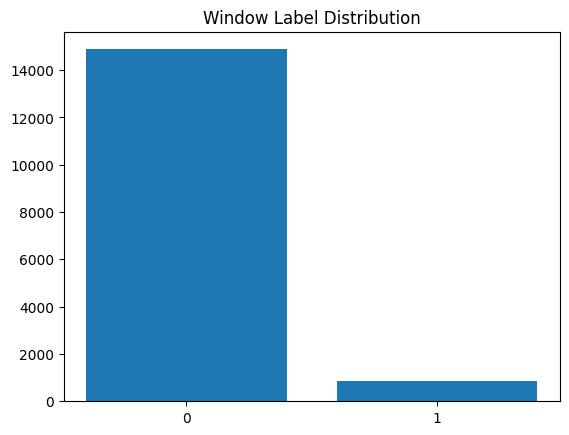

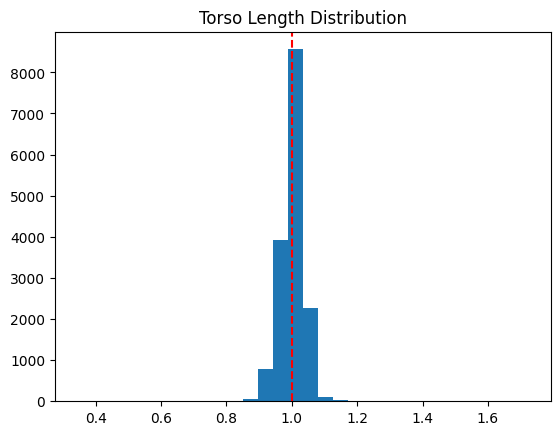

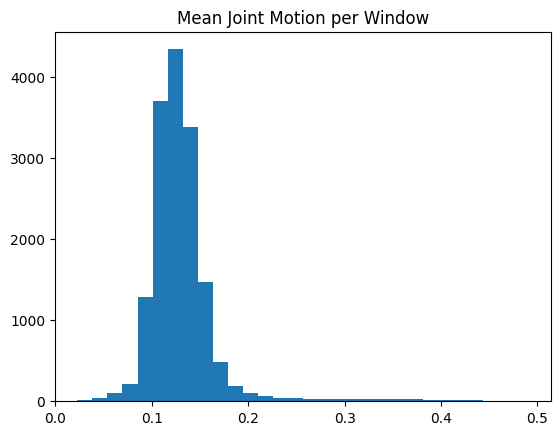

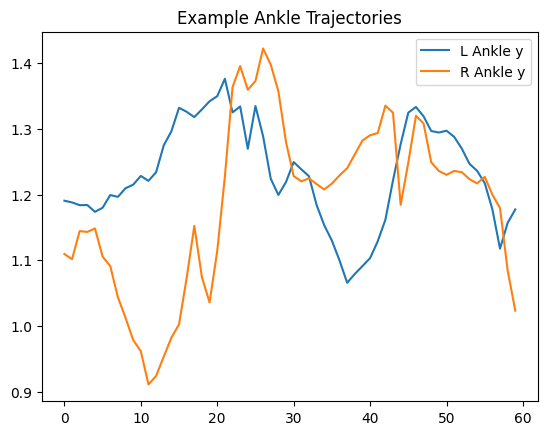

,0
num_windows,15752
invalid_windows,0
pelvis_offset_mean,0.0
pelvis_offset_95pct,0.0
torso_length_mean,1.00224
torso_length_std,0.037806
low_motion_windows,788
label_distribution,"{0: 14877, 1: 875}"


In [38]:
summary = sliding_window_quality_check_simple(X_windows, y_labels, plot=True)
display(pd.DataFrame.from_dict(summary, orient="index"))

In [ ]:
# Quality Controls

import numpy as np
from scipy.signal import find_peaks

def qc_gait_window(window, fps, visualize=False, title=""):
    """
    QC for a single sliding window.
    
    window: (T, J, 3) where J == len(GAIT_JOINTS)
    fps: frames per second for this window
    """

    # ---- Joint index mapping (LOCAL, reduced joints) ----
    GAIT_JOINT_INDEX = {jid: i for i, jid in enumerate(GAIT_JOINTS)}

    L_HIP = GAIT_JOINT_INDEX[23]
    R_HIP = GAIT_JOINT_INDEX[24]
    L_SHOULDER = GAIT_JOINT_INDEX[11]
    L_KNEE = GAIT_JOINT_INDEX[25]
    L_ANKLE = GAIT_JOINT_INDEX[27]

    qc = {}

    # -----------------------------
    # 1) Length / duration
    # -----------------------------
    qc["n_frames"] = window.shape[0]
    qc["duration_s"] = window.shape[0] / fps
    qc["flag_short"] = qc["duration_s"] < 1.0   # relaxed vs clip-based QC

    # -----------------------------
    # 2) Pelvis centering
    # -----------------------------
    pelvis = (window[:, L_HIP] + window[:, R_HIP]) / 2
    qc["pelvis_offset"] = np.linalg.norm(pelvis.mean(axis=0))
    qc["flag_off_center"] = qc["pelvis_offset"] > 0.1

    # -----------------------------
    # 3) Torso length stability
    # -----------------------------
    torso = window[:, L_SHOULDER] - pelvis
    torso_len = np.linalg.norm(torso, axis=1)
    qc["torso_mean_length"] = torso_len.mean()
    qc["torso_std_length"] = torso_len.std()
    qc["flag_torso_unstable"] = qc["torso_std_length"] > 0.15

    # -----------------------------
    # 4) Smoothness / jitter (ankle Y)
    # -----------------------------
    ankle_y = window[:, L_ANKLE, 1]
    ankle_y_vel = np.diff(ankle_y)
    qc["ankle_y_velocity_std"] = np.std(ankle_y_vel)
    qc["flag_jitter"] = qc["ankle_y_velocity_std"] > 0.2

    # -----------------------------
    # 5) Weak periodicity (knee Y)
    # -----------------------------
    knee_y = window[:, L_KNEE, 1]
    min_peak_dist = int(0.4 * fps)
    peaks, _ = find_peaks(knee_y, distance=min_peak_dist)

    qc["n_knee_peaks"] = len(peaks)
    qc["flag_no_periodicity"] = qc["n_knee_peaks"] < 1

    # -----------------------------
    # 6) Depth stability (ankle Z)
    # -----------------------------
    ankle_z = window[:, L_ANKLE, 2]
    qc["ankle_z_range"] = ankle_z.max() - ankle_z.min()
    qc["ankle_z_spike"] = np.max(np.abs(np.diff(ankle_z)))
    qc["flag_flat_depth"] = qc["ankle_z_range"] < 0.05

    # -----------------------------
    # Overall QC decision
    # -----------------------------
    qc["qc_fail"] = any([
        qc["flag_short"],
        qc["flag_off_center"],
        qc["flag_jitter"],
        qc["flag_no_periodicity"],
        qc["flag_flat_depth"],
        qc["flag_torso_unstable"]
    ])

    # -----------------------------
    # Optional visualization
    # -----------------------------
    if visualize:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(knee_y)
        plt.title(f"{title} – Knee Y")
        plt.subplot(1,2,2)
        plt.plot(ankle_z)
        plt.title(f"{title} – Ankle Z")
        plt.show()

    return qc


In [57]:
def apply_qc_windows(X_windows, y_labels, window_ids, fps=60):
    """
    Apply QC to sliding windows.
    
    Returns:
        X_clean, y_clean, window_ids_clean
        qc_df (with all QC flags)
    """
    qc_rows = []
    for i, window in enumerate(X_windows):
        qc = qc_gait_window(window, fps=fps, visualize=False, title=f"Window {i}")
        qc_rows.append(qc)

    qc_df = pd.DataFrame(qc_rows)
    qc_df["label"] = y_labels
    qc_df["window_id"] = window_ids

    # QC-clean mask
    keep_mask = ~qc_df["qc_fail"].values
    X_clean = X_windows[keep_mask]
    y_clean = y_labels[keep_mask]
    window_ids_clean = window_ids[keep_mask]

    print(f"QC-clean windows: {len(X_clean)} / {len(X_windows)} ({100*len(X_clean)/len(X_windows):.2f}%)")
    return X_clean, y_clean, window_ids_clean, qc_df

In [51]:
qc_rows = []

for i, window in enumerate(X_windows):
    qc = qc_gait_window(
        window,
        fps=60,              # or pass per-window FPS if you have it
        visualize=False,
        title=f"Window {i}"
    )
    qc_rows.append(qc)

qc_df = pd.DataFrame(qc_rows)


print("Total windows:", len(X_windows))
print("QC fail count:", qc_df["qc_fail"].sum())
print("QC fail %:", 100 * qc_df["qc_fail"].mean())

qc_df[[
    'flag_short',
    'flag_off_center',
    'flag_jitter',
    'flag_no_periodicity',
    'flag_flat_depth',
    'flag_torso_unstable'
]].sum()


Total windows: 15752
QC fail count: 751
QC fail %: 4.767648552564753


flag_short               0
flag_off_center          0
flag_jitter            401
flag_no_periodicity      0
flag_flat_depth          0
flag_torso_unstable    500
dtype: int64

In [ ]:
def preprocessing_pipeline(df_video,
                           window_seconds=2.0,
                           overlap=0.5,
                           resample_frames=60,
                           fps_default=60,
                           qc_fps=60):
    """
    End-to-end pipeline:
    1. Sliding window extraction
    2. QC filtering
    
    Returns:
        X_clean, y_clean, window_ids_clean, qc_df
    """
    X_windows, y_labels, window_ids = preprocess_sliding_windows(
        df_video,
        window_seconds=window_seconds,
        overlap=overlap,
        resample_frames=resample_frames,
        fps_default=fps_default
    )

    X_clean, y_clean, window_ids_clean, qc_df = apply_qc_windows(
        X_windows,
        y_labels,
        window_ids,
        fps=qc_fps
    )

    return X_clean, y_clean, window_ids_clean, qc_df

In [ ]:
# Mask for QC-clean windows
keep_mask = ~qc_df["qc_fail"].values

# Subset windows and labels
X_windows_clean = X_windows[keep_mask]
y_labels_clean = y_labels[keep_mask]

print("Windows after QC:", X_windows_clean.shape[0])


In [54]:
qc_df["label"] = y_labels

qc_fail_by_label = (
    qc_df.groupby("label")["qc_fail"]
    .mean()
    .rename(index={0: "Normal", 1: "Abnormal"})
)

qc_fail_by_label



label
Normal      0.046448
Abnormal    0.068571
Name: qc_fail, dtype: float64

In [56]:
summary_counts = (
    qc_df.groupby(["label", "qc_fail"])
    .size()
    .unstack(fill_value=0)
    .rename(
        index={0: "Normal", 1: "Abnormal"},
        columns={False: "QC_pass", True: "QC_fail"}
    )
)

summary_counts

qc_fail,QC_pass,QC_fail
label,,
Normal,14186,691
Abnormal,815,60
